In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
stocks = ['KO', 'PEP', 'NVDA','KSU']
seq_len = 150

id = 'vb7m8jvt'
path_storage = f'storage/{id}'

seed, epoch = 42, 5
file_name = f'synthetics_epoch={epoch}_seed={seed}'

In [11]:
def make_plot(returns_real, returns_synthetic, xlim):  
    bins = np.linspace(xlim[0], xlim[1], 75)

    fig, axes = plt.subplots(2, 2, figsize=(8, 5))
    axes = axes.ravel()

    add_label = True
    for ax, stock_name, real, synthetic in zip(axes, stocks, returns_real, returns_synthetic):
        ax.set_title(stock_name)
        ax.set_xlim(xlim)
        ax.hist(
            x=[synthetic, real], bins=bins, 
            label=["Synthetic", "Real"] if add_label else None, color=["C2", "C1"],
            density=True, log=True, histtype="step", linewidth=2
        )
        ax.hist(
            x=[synthetic, real], bins=bins, 
            color=["C2", "C1"],
            density=True, log=True, histtype="stepfilled", alpha=.3
        )
        add_label = False
        ax.set_facecolor('#eaeaf2')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.tick_params(bottom=False, left=False, which='both')
        ax.grid(True, linestyle='solid', c='w')

    fig.legend(loc="upper center", ncol=2)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [12]:
real = pd.read_csv('data/stocks/midprice_volume__KO_PEP_NVDA_KSU__train.csv', index_col=0)[[f'mid_price_{s}' for s in stocks]].values
real = np.asarray([real[i*seq_len:(i+1)*seq_len] for i in range(len(real) // seq_len)])
n_samples = len(real)

with open(f'{path_storage}/inference_data/guidance_scale=250/critic_epoch=121/{file_name}.npy', 'rb') as f:
    synthetic = np.load(f)
indices = np.random.choice(len(synthetic), n_samples, replace=False)
synthetic = synthetic[indices]

In [13]:
minutely_returns_real = np.diff(np.log(real), axis=1).reshape(len(stocks), -1)
minutely_returns_synthetic = np.diff(np.log(synthetic), axis=1).reshape(len(stocks), -1)

n_minutes = 15
n_minutely_returns_real = np.diff(np.log(real[:, ::n_minutes, :]), axis=1).reshape(len(stocks), -1)
n_minutely_returns_synthetic = np.diff(np.log(synthetic[:, ::n_minutes, :]), axis=1).reshape(len(stocks), -1)

xlim = [
    min(
        minutely_returns_real.min(),
        minutely_returns_synthetic.min(),
        n_minutely_returns_real.min(),
        n_minutely_returns_synthetic.min(),
    ),
    max(
        minutely_returns_real.max(),
        minutely_returns_synthetic.max(),
        n_minutely_returns_real.max(),
        n_minutely_returns_synthetic.max(),
    ),
]

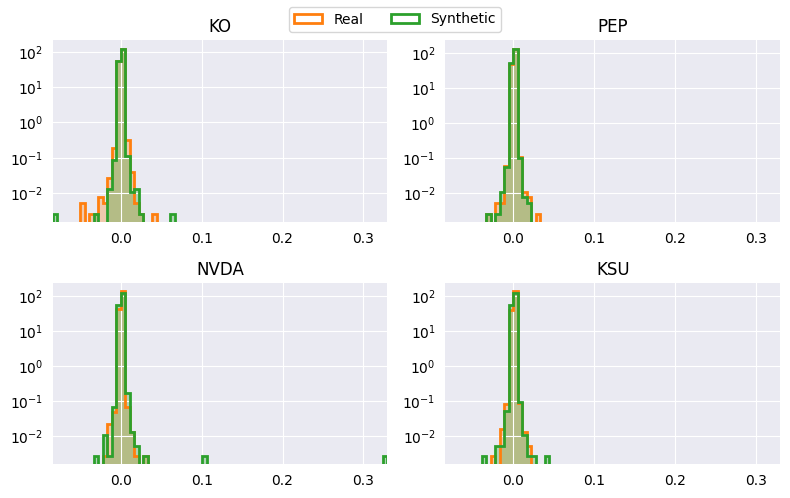

In [14]:
make_plot(minutely_returns_real, minutely_returns_synthetic, xlim)

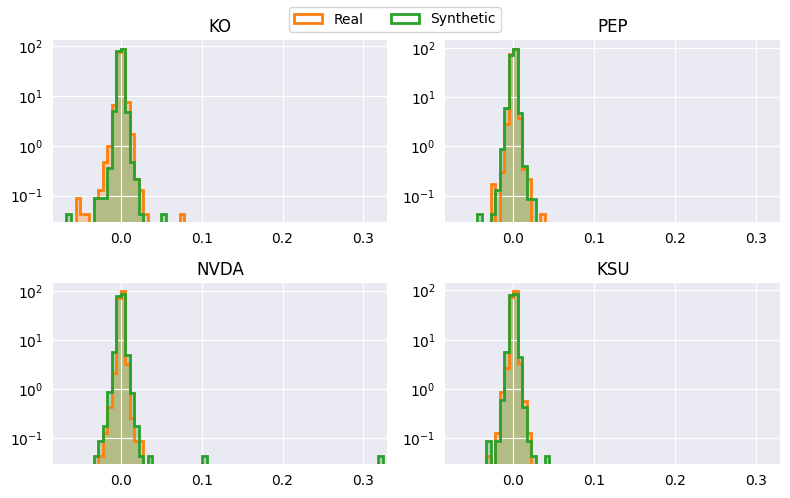

In [15]:
make_plot(n_minutely_returns_real, n_minutely_returns_synthetic, xlim)